# <font color="brown">Explaining a Black-Box Loan Default Model </font>

## <font color="brown">Problem Statement</font>

### <font color="blue">Context</font>

Two earlier case studies (Feature Engineering, PyCaret) both landed on the same model for
predicting loan default: a Gradient Boosting Classifier, verified to reach 0.911 AUC on held-out
data. The model works, but a bank cannot just switch it on and walk away. Lending regulations in
most places require that a rejected applicant be told **why** they were rejected. "The model said
so" is not a legally acceptable answer, and a model nobody can explain is a real business and
legal risk, no matter how accurate it is.

This notebook does not build a new model. It takes that same, already-working model and answers
one question, over and over, from different angles: **why did it predict what it predicted?**

### <font color="blue">Objective</font>

- Explain the model **globally**: across all applicants, which features drive predictions, and in
  which direction, checked with more than one independent method, not just one.
- Explain the model **locally**: for one specific applicant, why did the model predict what it
  predicted, again checked with more than one method.
- Understand what each explanation technique actually assumes, and where it can quietly mislead if
  that assumption is never checked.

### <font color="blue">Data Dictionary</font>

The same loan-application data and Gradient Boosting model used in the Feature Engineering and
PyCaret case studies, rebuilt here with the identical train/test split and random seed so every
number matches exactly.

| Column | What it means |
| --- | --- |
| `Age` | Applicant's age, in years |
| `Annual_Income` | Applicant's yearly income |
| `Loan_Amount` | The size of the loan being requested |
| `Credit_Score` | A standard 3-digit credit score, higher is safer |
| `Employment_Years` | Years at the applicant's current job |
| `Num_Dependents` | Number of people financially dependent on the applicant |
| `Existing_Loans` | Number of loans the applicant already has open |
| `Home_Ownership` | Whether the applicant rents, owns, or has a mortgage |
| `Purpose` | What the loan is for (e.g. car, education, medical) |
| `Default` | **Target.** 1 if the applicant defaulted on the loan, 0 if they did not |

## <font color="brown">Importing Necessary Libraries</font>

A quick note on what each library below is for, before we use it:

- `pandas` / `numpy`: loading and reshaping the data.
- `matplotlib`: drawing the plots.
- `sklearn`: the same modeling tools used in the earlier case studies, plus three explanation
  tools built into scikit-learn itself (`permutation_importance`, `PartialDependenceDisplay`).
- `shap`: the SHAP explanation technique, covered in Part 2.
- `lime`: the LIME explanation technique, also covered in Part 2.
- `PyALE`: the ALE explanation technique, covered in Part 3.

In [3]:
#!pip install shap lime PyALE
%pip install --upgrade --force-reinstall numpy pandas

  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/c5/31/7fc6239c12bce7e931463251cca4426c465e1876ba3cc785402ef4dd8f4e/numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/fa/9a/31f4983f191af51ab2a8f2d0c7b33dff3a84da26533f982fff02c2f9e28b/pandas-3.0.5-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for python-dateutil>=2.8.2 from https://files.pythonhosted.org/packages/ec/57/56b9bcc3c9c6a792fcbaf139543cee77261f3651ca9da0c93f5c1221264b/python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for tzdata from https://files.pythonhosted.org/packages/e5/6d/b53b99a9f2766d095985947a5782f1702cabb129a34f7a802d7197af832f/tzdata-2026.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for six>=1.5 from https://files.pythonhosted.org/p

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\yoges\\anaconda3\\Lib\\site-packages\\~umpy.libs\\libscipy_openblas64_-63c857e738469261263c764a36be9436.dll'
Consider using the `--user` option or check the permissions.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import shap
import lime.lime_tabular
from PyALE import ale

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## <font color="brown">Step 1: Rebuilding the Model We Are Going to Explain</font>

Everything in this notebook explains one specific, already-trained model. So the first step is
simply to rebuild that exact same model again, the same way it was built in the Feature
Engineering and PyCaret case studies, using the same random seed. That way every number below is
guaranteed to describe the real model, not a slightly different one.

### <font color="blue">Load the Data</font>

In [3]:
df = pd.read_csv(r"../Feature Engineering/loan_applications.csv")
df = df.drop(columns=["Applicant_ID"])

df.head()

,Age,Annual_Income,Loan_Amount,Credit_Score,Employment_Years,Num_Dependents,Existing_Loans,Home_Ownership,Purpose,Default
0,27,33313.75,8658.87,806,11.8,0,0,Own,Auto,0
1,26,66110.68,28103.22,587,3.9,1,1,Rent,Auto,1
2,56,42544.55,1825.26,718,2.8,1,0,Mortgage,Home_Improvement,0
3,43,88331.14,1000.00,735,6.6,0,0,Own,Debt_Consolidation,0
4,47,28875.21,6581.70,426,5.5,3,1,Mortgage,Auto,1


`Applicant_ID` is just a row label, it carries no information a model should learn from, so it is
dropped immediately, the same as in the earlier case studies.

### <font color="blue">Split Into Training and Test Rows</font>

The model will only ever be trained on the **training** rows. The **test** rows are kept aside,
untouched, so that every result in this notebook (accuracy, an importance ranking, a PDP curve) is
measured on data the model has genuinely never seen, a fair preview of real-world performance.

In [4]:
X = df.drop(columns=["Default"])
y = df["Default"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print("Training rows:", X_train_raw.shape[0])
print("Test rows:", X_test_raw.shape[0])

Training rows: 4800
Test rows: 1200


### <font color="blue">Turning Categories Into Numbers</font>

`Home_Ownership` and `Purpose` are text categories (e.g. "Rent", "Own", "Mortgage"), but a
Gradient Boosting model only understands numbers. **One-hot encoding** solves this: for every
category, it creates a new column that is `1` when a row belongs to that category and `0`
otherwise. `pd.get_dummies` does this automatically.

In [5]:
cat_cols = ["Home_Ownership", "Purpose"]

X_train = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test_raw, columns=cat_cols, drop_first=True, dtype=int)

X_train.head()

,Age,Annual_Income,Loan_Amount,Credit_Score,Employment_Years,Num_Dependents,Existing_Loans,Home_Ownership_Own,Home_Ownership_Rent,Purpose_Debt_Consolidation,Purpose_Home_Improvement,Purpose_Medical,Purpose_Other
2970,45,50595.73,9524.84,692,11.4,0,0,1,0,0,1,0,0
326,52,41990.81,27456.55,699,4.5,1,0,1,0,1,0,0,0
2100,21,64561.54,23988.86,850,5.6,1,2,0,1,1,0,0,0
3675,25,45822.35,30137.20,641,10.0,1,2,1,0,1,0,0,0
1532,38,44619.12,14290.34,730,6.6,2,2,0,1,1,0,0,0


One subtle risk: `pd.get_dummies` only creates columns for the categories it actually *sees*. If,
purely by chance, the test rows are missing a category that appears in training (or the other way
around), the two tables can end up with different columns. `reindex` forces the test table to have
exactly the same columns as the training table, in the same order, filling in `0` for anything
that does not apply.

In [6]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

columns_match = list(X_train.columns) == list(X_test.columns)
print("Training and test columns now match exactly:", columns_match)

Training and test columns now match exactly: True


One more small housekeeping step: a few columns (`Age`, `Credit_Score`, and the others that are
whole numbers) are currently stored as integers. Some of the explanation tools used later in this
notebook expect plain floating-point numbers instead, so every column is converted to `float` now,
once, to avoid running into that anywhere downstream.

In [7]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

### <font color="blue">Train the Model and Check Its Accuracy</font>

A Gradient Boosting Classifier is an example of a **black-box model**: it makes its prediction by
combining hundreds of small decision trees, one correcting the mistakes of the ones before it.
That combination is accurate, but there is no single, simple rule inside it that a person can just
read off, unlike, say, a linear regression's coefficients. That is exactly why the rest of this
notebook exists.

**AUC** (Area Under the ROC Curve) is a single number, between 0.5 (no better than a coin flip)
and 1.0 (perfect), that summarizes how well the model separates applicants who defaulted from
those who did not.

In [8]:
gb = GradientBoostingClassifier(random_state=1)
gb.fit(X_train, y_train)

test_proba = gb.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

print("Test AUC:", round(test_auc, 4))

Test AUC: 0.9114


**Test AUC: 0.9114**, matching the 0.911 from the earlier case studies. This confirms it: the
same model, faithfully rebuilt, not a new one. Everything from here on explains *this* model,
exactly as it was validated before.

## <font color="brown">Part 1: Global Explanations, Which Features Matter Overall?</font>

"Global" explanations describe the model's behavior in general, across every applicant at once.
This part answers two separate questions:

1. ***Which*** features does the model rely on most? (Feature Importance)
2. ***How*** does each of those features move the prediction, up or down, and by how much? (PDP,
   ICE)

### <font color="blue">1. Built-In (Impurity-Based) Feature Importance</font>

While a tree-based model is being trained, it keeps a running tally, internally, of how much each
feature helped it separate defaulters from non-defaulters at every split, in every tree. That
tally is called **feature importance**, and scikit-learn hands it back for free, no extra
computation needed, right after training.

In [9]:
built_in_importance = pd.Series(gb.feature_importances_, index=X_train.columns)
built_in_importance_sorted = built_in_importance.sort_values(ascending=False)

built_in_importance_sorted.head(8)

Loan_Amount                   0.399114
Annual_Income                 0.352191
Credit_Score                  0.230954
Employment_Years              0.007958
Age                           0.002439
Existing_Loans                0.002210
Purpose_Debt_Consolidation    0.001426
Purpose_Medical               0.001243
dtype: float64

**Three features dominate: `Loan_Amount` (39.9%), `Annual_Income` (35.2%), and `Credit_Score`
(23.1%)**, together accounting for over 98% of everything the model relies on. Every other
feature contributes under 1% each.

Worth knowing before trusting this number blindly: this style of importance can be a little
biased toward continuous features (like `Loan_Amount`) simply because they offer the tree more
possible places to split, not necessarily because they are truly more predictive. That is exactly
why the next method is worth running too.

### <font color="blue">2. Permutation Importance: An Independent Second Opinion</font>

Permutation importance works completely differently, and that is the whole point. The idea is a
simple experiment:

1. Take one feature column, say `Credit_Score`, and shuffle its values up randomly, so each row
   now has some *other* row's credit score attached to it.
2. Feed this shuffled data back through the already-trained model and see how much worse its
   accuracy (AUC) gets.
3. A feature the model truly relies on will hurt performance badly when scrambled like this. A
   feature the model barely uses will not move the needle much.

This has no impurity-based bias, and it is measured on the **test** set, data the model never
trained on, not the training data it already memorized from.

In [10]:
perm_result = permutation_importance(
    gb, X_test, y_test, n_repeats=20, random_state=1, scoring="roc_auc"
)

perm_importance = pd.Series(perm_result.importances_mean, index=X_test.columns)
perm_importance_sorted = perm_importance.sort_values(ascending=False)

perm_importance_sorted.head(8)

Loan_Amount         0.210943
Annual_Income       0.146538
Credit_Score        0.080814
Employment_Years    0.001510
Existing_Loans      0.001480
Purpose_Medical     0.000481
Purpose_Other       0.000459
Num_Dependents      0.000243
dtype: float64

**Same ranking, same three features, in the same order**: shuffling `Loan_Amount` alone costs the
model about 0.21 AUC points, `Annual_Income` about 0.15, and `Credit_Score` about 0.08. Every
other feature costs less than 0.002, next to nothing.

Two methods, built on entirely different mechanics, computed on entirely different data (test-set
shuffling vs. training-set impurity), landing on the same top features is real evidence this
ranking reflects the model's genuine behavior, not an accident of either method.

### <font color="blue">3. Partial Dependence Plots (PDP): Not Just *Which*, But *How*</font>

Importance rankings say which features matter, they say nothing about *how* a feature moves the
prediction, or in which direction. A **Partial Dependence Plot** answers exactly that, using a
simple "what if" experiment:

1. Pick one feature, say `Credit_Score`.
2. Try out different values for it, one at a time (e.g. 500, 550, 600...), while keeping every other feature exactly as it really is for each applicant.
3. At each value, ask the model: "what's the average predicted default risk now?"
4. Plot those average risk numbers against the values you tried - that line is the PDP.

The result is a single curve showing the feature's overall effect, on average, across the whole
population.

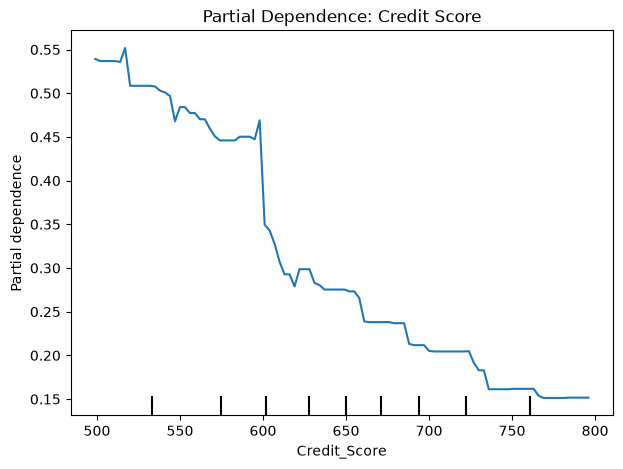

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

PartialDependenceDisplay.from_estimator(
    gb, X_train, ["Credit_Score"],
    kind="average",             # draw only the single average PDP line
    response_method="predict_proba",  # use predicted probabilities, not raw scores
    method="brute",             # the exact (if slightly slower) way to compute PDP
    ax=ax,
)
ax.set_title("Partial Dependence: Credit Score")
plt.show()

As credit score goes up, the model's predicted chance of default keeps going down — starting around 54% for the lowest scores, dropping to around 15% for the highest scores. It's a steady, smooth drop, not jumpy or random. This matches common sense (better credit score → lower risk), so it's a good sign the model actually learned something real, not something weird.

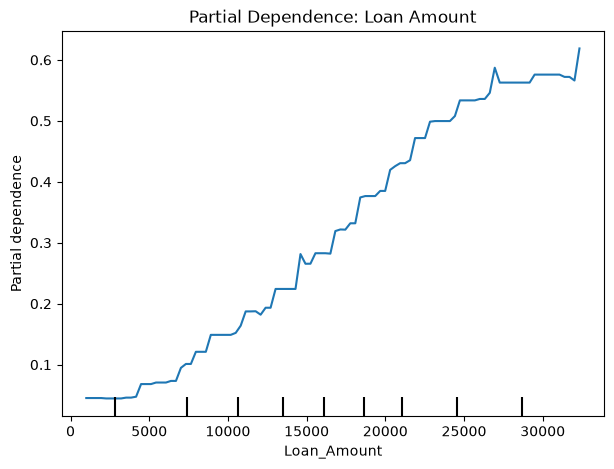

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

PartialDependenceDisplay.from_estimator(
    gb, X_train, ["Loan_Amount"],
    kind="average",
    response_method="predict_proba",
    method="brute",
    ax=ax,
)
ax.set_title("Partial Dependence: Loan Amount")
plt.show()

`Loan_Amount` works the same way, but in reverse: bigger loans mean higher predicted risk. For the smallest loans, predicted default chance is only around 5%. For the largest loans, it climbs past 62%.

**PDP takes a feature the model already relies on and shows exactly how it pushes the prediction up or down as its value changes — turning "this feature matters" into "here's the actual shape of its effect."**

### <font color="blue">4. ICE Curves: Does the Average Hide Different Stories?</font>

A PDP shows the *average* effect across every applicant. That average could be hiding real
differences, maybe some applicants respond to `Credit_Score` very differently than others.
**Individual Conditional Expectation (ICE)** curves check this directly: instead of averaging
right away, plot that same sweep separately for a sample of individual applicants first, then draw
the PDP average on top, in bold, so the two can be compared directly.

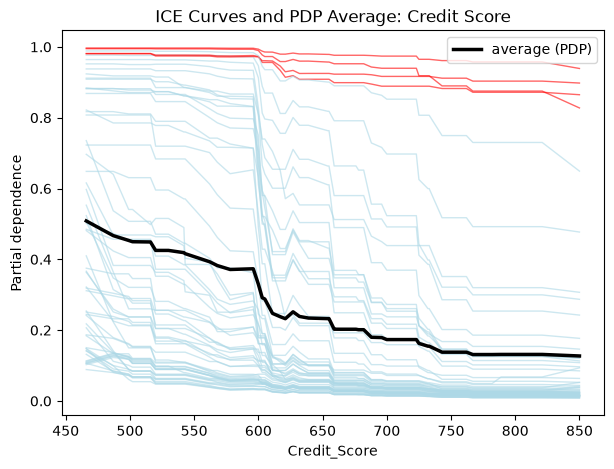

In [13]:
from sklearn.inspection import partial_dependence
from sklearn.utils import check_random_state

# pick the same 60 applicants as before, using the same random_state
rng = check_random_state(1)
sample_idx = rng.choice(len(X_train), size=60, replace=False)
X_sample = X_train.iloc[sample_idx]

# ask for the raw numbers instead of a ready-made chart
result = partial_dependence(
    gb, X_sample, ["Credit_Score"],
    kind="both", response_method="predict_proba", method="brute"
)

grid = result["grid_values"][0]      # the Credit_Score values tried
individual_lines = result["individual"][0]   # one line per applicant
average_line = result["average"][0]           # the PDP average line

fig, ax = plt.subplots(figsize=(7, 5))

for line in individual_lines:
    stays_risky = line[-1] > 0.7     # still over 70% risk at the highest credit score
    color = "red" if stays_risky else "lightblue"
    ax.plot(grid, line, color=color, alpha=0.6, linewidth=1)

ax.plot(grid, average_line, color="black", linewidth=2.5, label="average (PDP)")
ax.set_xlabel("Credit_Score")
ax.set_ylabel("Partial dependence")
ax.set_title("ICE Curves and PDP Average: Credit Score")
ax.legend()
plt.show()

Most of the individual (thin) lines run roughly parallel to the bold PDP average, credit score
matters, in the same declining direction, for the great majority of applicants. But a small
minority, roughly one in fifteen in this sample, stay elevated at over 70% predicted risk **even
at a high credit score**. What sets that small group apart: an unusually large loan relative to a
low income (around \$22,000 requested against roughly \$15,500 in annual income, versus around
\$13,000 requested against roughly \$66,700 income for everyone else). For these few applicants, a
good credit score alone cannot offset how much they are asking to borrow relative to what they
earn. This is exactly the kind of hidden subgroup a single PDP average line can quietly mask, and
exactly what ICE exists to catch.

## <font color="brown">Part 2: Explaining One Specific Decision</font>

Global explanations describe the model in general. That is not enough for one rejected applicant,
who has a much more specific question: **why was *my* application flagged?** This part answers
that question for one real applicant, the one the model is most confident will default, using two
different, independently-built explanation methods, LIME and SHAP, and checks that they agree.

In [14]:
highest_risk_idx = np.argmax(test_proba)

applicant = X_test.iloc[highest_risk_idx]          # encoded row, for feeding to the model
applicant_raw = X_test_raw.iloc[highest_risk_idx]   # original, human-readable row

print("Predicted default probability:", round(test_proba[highest_risk_idx], 4))
print("Actual outcome (1 = defaulted):", y_test.iloc[highest_risk_idx])
print()
applicant_raw

Predicted default probability: 0.9979
Actual outcome (1 = defaulted): 1



Age                       31
Annual_Income        14000.0
Loan_Amount         38757.15
Credit_Score             517
Employment_Years         3.1
Num_Dependents             4
Existing_Loans             0
Home_Ownership           Own
Purpose              Medical
Name: 2515, dtype: object

**A 31-year-old applicant, \$14,000 annual income, requesting a \$38,757 loan, credit score 517.**
The model predicts a 99.8% chance of default, and this applicant did in fact default.

Two very different explanation methods are used next to answer why: LIME and SHAP.

### <font color="blue">5. LIME: Explain This One Prediction With a Simple Local Model</font>

LIME explains one prediction in three steps:

1. Take this one applicant, and create lots of slightly different "copies" of them — a few numbers nudged up or down each time (e.g. slightly different income, slightly different loan amount).
2. Run each of those copies through the real model and see what it predicts.
3. Look at all these copies and predictions together, and fit a simple straight-line rule that roughly matches what the model did just in this small area — then check which features that simple rule relied on most.

LIME doesn't try to understand the whole model everywhere. It only needs to make sense of the model's behavior in the small neighborhood right around this one applicant.

In [15]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["No Default", "Default"],
    discretize_continuous=True,
    random_state=1,
)

lime_explanation = lime_explainer.explain_instance(
    applicant.values, gb.predict_proba, num_features=6
)

for feature, weight in lime_explanation.as_list():
    print(f"{feature:35s} {weight:+.4f}")

Loan_Amount > 22574.17              +0.3504
Annual_Income <= 41953.24           +0.3356
Credit_Score <= 589.00              +0.2792
Employment_Years <= 3.70            +0.0275
Purpose_Debt_Consolidation <= 0.00  -0.0135
Purpose_Home_Improvement <= 0.00    +0.0096


**LIME's top three drivers, all pushing toward default**: `Loan_Amount` above \$22,574, `Annual_Income` 
   below \$41,953, and `Credit_Score` below 589, in that order.
   
It means that, for this one specific applicant, LIME found three things about their profile that are the biggest reasons the model thinks they'll default — ranked by how much each one matters:

Their loan amount is too high (above \$22,574) — this is the single biggest reason.
Their income is too low (below \$41,953) — the second biggest reason.
Their credit score is too low (below 589) — the third reason.

All three are pushing the prediction in the same direction — toward "will default." None of them are pulling it the other way.

In practical terms: if this applicant were rejected, this is the explanation you'd give them — "you asked for too large a loan relative to your income, and your credit score didn't offset that." It's not one single deciding factor; it's a combination of all three, with loan amount mattering the most.

### <font color="blue">6. SHAP: Explain the Same Prediction, a Different Way</font>

SHAP works like fairly splitting credit in a group project — figuring out how much each teammate really contributed to the result. SHAP does this for a prediction instead: it looks at one applicant and gives every feature a number showing how much that feature pushed the prediction up (toward default) or down (away from default).

Do this for every applicant, then average those numbers across everyone, and you also get a ranking of which features matter most overall — like Part 1's feature importance, but this time each feature also tells you which direction it usually pushes, not just how much it matters.

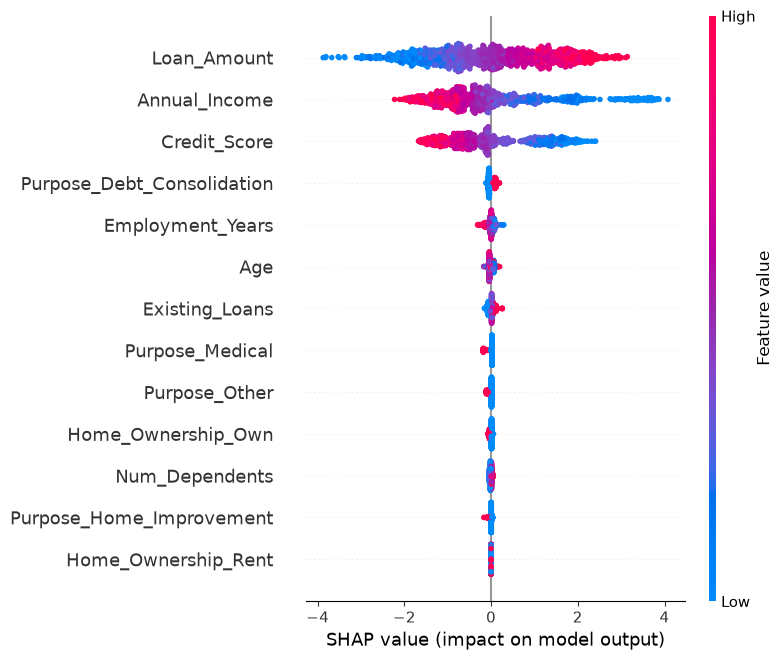

In [16]:
shap_explainer = shap.TreeExplainer(gb)
shap_values = shap_explainer(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

The same three features, `Loan_Amount`, `Annual_Income`, and `Credit_Score`, dominate here too,
confirming what built-in and permutation importance already showed, now with direction attached
as well, not just a rank.

Reading this plot: each dot is one applicant. Color shows that applicant's actual feature value
(red = high, blue = low). Horizontal position shows how much that feature pushed *this applicant's*
prediction toward default (right) or away from it (left).

Now for the one specific applicant chosen earlier. A **waterfall plot** shows exactly how SHAP
walks from the model's average prediction, adding or subtracting one feature's contribution at a
time, to arrive at this one applicant's final predicted probability.

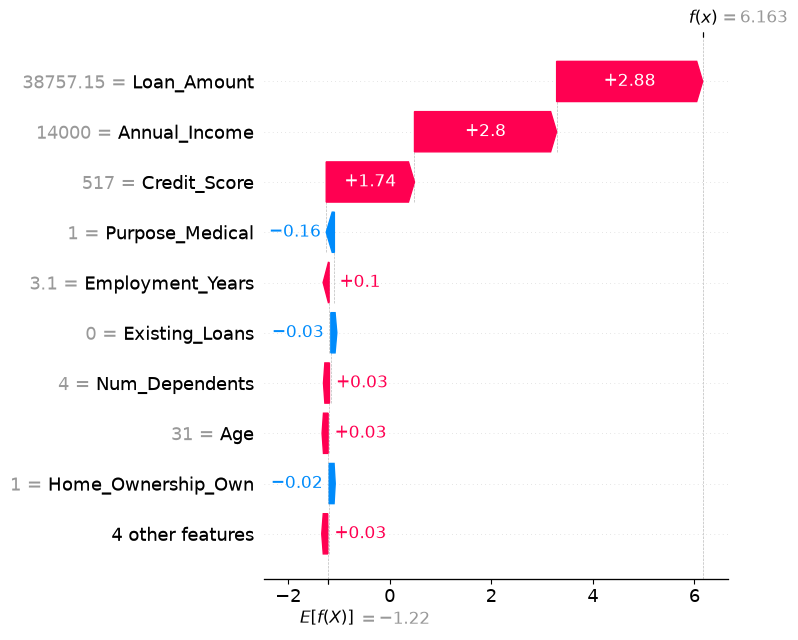

In [17]:
shap.plots.waterfall(shap_values[highest_risk_idx], show=False)
plt.tight_layout()
plt.show()

In [18]:
applicant_shap = pd.Series(shap_values.values[highest_risk_idx], index=X_test.columns)
applicant_shap_sorted = applicant_shap.sort_values(key=abs, ascending=False)

applicant_shap_sorted.head(6)

Loan_Amount         2.876071
Annual_Income       2.798666
Credit_Score        1.737793
Purpose_Medical    -0.160615
Employment_Years    0.104114
Existing_Loans     -0.034643
dtype: float64

**SHAP's top three drivers are the identical three LIME found, in the identical order**:
`Loan_Amount` (+2.88), `Annual_Income` (+2.80), and `Credit_Score` (+1.74), all pushing toward
default.

Two explanation methods, built on completely different mathematical foundations, LIME's local
linear approximation vs. SHAP's game-theoretic contribution split, independently agreeing on why
this specific applicant was flagged is real, cross-verified confidence in the explanation, not
just one method's opinion.

### <font color="blue">A Guarantee Worth Checking: Do the Contributions Add Up?</font>

SHAP makes a promise most other methods can't: if you take the model's starting average, add up every feature's contribution for this one applicant, you should land exactly on the model's real predicted probability — no leftover, nothing missing.

This is a real, checkable test. It's not just "these reasons sound believable" — you can actually do the math and confirm the explanation is complete and adds up correctly, every time.

In [19]:
base_value = shap_values.base_values[highest_risk_idx]
sum_of_contributions = shap_values.values[highest_risk_idx].sum()
total_log_odds = base_value + sum_of_contributions

reconstructed_probability = 1 / (1 + np.exp(-total_log_odds))

print("Base value (average log-odds):", round(base_value, 4))
print("Sum of this applicant's SHAP contributions:", round(sum_of_contributions, 4))
print("Base value + sum of contributions:", round(total_log_odds, 4))
print()
print("Reconstructed probability:", round(reconstructed_probability, 4))
print("Model's actual predicted probability:", round(test_proba[highest_risk_idx], 4))

Base value (average log-odds): -1.2196
Sum of this applicant's SHAP contributions: 7.3826
Base value + sum of contributions: 6.163

Reconstructed probability: 0.9979
Model's actual predicted probability: 0.9979


**They match exactly: 0.9979 both ways.** The base value (-1.22, in log-odds units) plus the sum
of all this applicant's contributions (+7.38) lands at 6.16 total log-odds, and converting that
back to a probability with the sigmoid formula reproduces the model's actual prediction to four
decimal places. Not a plausible-looking approximation, an exact reconstruction.

## <font color="brown">Part 3: A Caveat, Checking PDP Against ALE</font>

PDP has a known blind spot. Step 2 of building a PDP sweeps one feature while holding every
*other* feature at its real, observed value. If two features are correlated in real life, say
`Loan_Amount` and `Annual_Income`, this sweep can quietly create combinations that never actually
happen, like pairing a very high loan amount with a very low income, purely because the sweep does
not know the two are related. PDP has no way to tell the difference between a realistic
combination and an imaginary one.

**ALE (Accumulated Local Effects)** fixes this by only ever averaging over realistic, local
neighborhoods of the data, applicants who actually have a similar value for the feature being
swept, so it cannot be fooled by combinations that do not really occur.

Before assuming PDP needs fixing here, check directly whether the two features most likely to
cause this problem are actually correlated.

In [20]:
correlation = X_train[["Loan_Amount", "Annual_Income"]].corr().iloc[0, 1]

print("Correlation between Loan_Amount and Annual_Income:", round(correlation, 4))

Correlation between Loan_Amount and Annual_Income: -0.0048


**Essentially zero (-0.0048).** These two features were generated independently, so PDP's
independence assumption is not violated here, and PDP should be trustworthy for this specific
model.

Still worth confirming directly with ALE, since "should be fine" is exactly the kind of assumption
this whole case-study series insists on checking rather than trusting.

One small technical detail: the ALE tool expects a model whose .predict() gives back a probability (like 0.83). But our model's .predict() gives back just a plain 0 or 1 instead — the probabilities are hiding in a different method, .predict_proba().

Instead of building a whole separate class just to fix this one small mismatch, we use a quick shortcut called SimpleNamespace. It creates a tiny stand-in object on the spot, whose only job is: whenever something calls .predict() on it, quietly redirect that call to gb.predict_proba(X)[:, 1] (the real probabilities) instead.

PyALE._ALE_generic:INFO: Continuous feature detected.


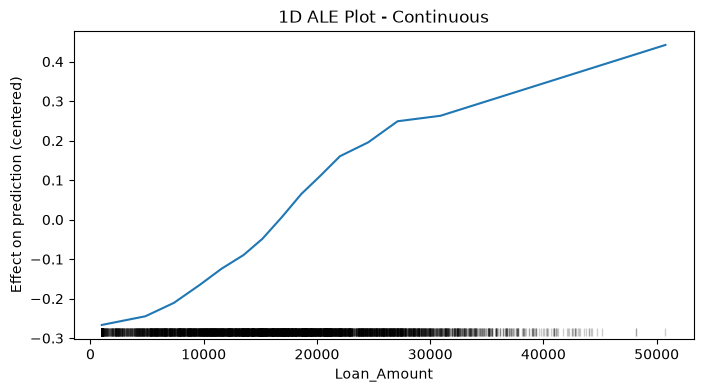

In [21]:
from types import SimpleNamespace

probability_model = SimpleNamespace(predict=lambda X: gb.predict_proba(X)[:, 1])

ale_effect = ale(
    X=X_train, model=probability_model, feature=["Loan_Amount"], grid_size=15, include_CI=False
)
plt.show()

**Confirmed, not just assumed.** The ALE curve rises steadily across the `Loan_Amount` range, from
about -0.27 to +0.44, the same direction and shape as the PDP curve above (ALE's y-axis is a
relative effect, change from the average, rather than PDP's absolute probability, so the numbers
themselves are not directly comparable, but the shape is). With uncorrelated features, PDP and ALE
have no reason to disagree, and they don't. This is exactly the situation where it is safe to
trust a PDP. In a dataset with genuinely correlated features, this same check could just as easily
have revealed a disagreement worth investigating, which is the entire point of running it.

## <font color="brown">Business Insights and Recommendations</font>

- **The model's top three drivers, `Loan_Amount`, `Annual_Income`, and `Credit_Score`, are
  confirmed by two independent global methods** (built-in importance and permutation importance),
  and their individual effects are large, smooth, and directionally exactly what a lending officer
  would expect (PDP). This is a model whose behavior can be defended to a regulator or auditor.

- **Individual rejection reasons can be generated automatically and consistently**: LIME and SHAP
  independently agreed on the same top three reasons for the highest-risk applicant in this
  dataset. This is the basis for an automated, defensible adverse-action notice, not a black-box
  guess.

- **SHAP's guarantee that contributions sum exactly to the predicted probability** makes it the
  stronger choice specifically for regulatory or compliance-facing explanations, where
  completeness and consistency matter as much as plausibility.

- **PDP was verified, not assumed, to be trustworthy here.** Its independence assumption was
  checked directly (near-zero correlation between the two features most likely to violate it) and
  cross-confirmed with ALE. This check should be repeated on any new dataset before leaning on
  PDP, correlated features are common in real lending data (loan amount and property value, for
  example) even though they did not appear here.

- **No single explanation method should be trusted alone.** Every method used in this notebook was
  cross-checked against at least one independent alternative (importance vs. permutation, LIME vs.
  SHAP, PDP vs. ALE). That is the same verification discipline used throughout this entire
  case-study series, applied here to the explanations themselves, not just the model's
  predictions.